In [3]:
import numpy as np
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import packages as rpackages
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from scipy.sparse import csr_matrix, issparse

r = ro.r
rcb.logger.setLevel(logging.ERROR)
sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, facecolor='white', frameon=False)

%load_ext rpy2.ipython

In [8]:
# REMOVE them after finalizing
adata = sc.read_10x_h5('filtered_feature_bc_matrix.h5')
adata_raw = sc.read_10x_h5('raw_feature_bc_matrix.h5')

/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
    np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

def filter_cells_by_mad(
    adata,
    mt_prefix,
    ribo_prefix,
    hb_prefix=r"^HB[^P]",
    top_gene_per=20,
    general_MAD=5,
    mt_MAD=3,
    mt_threshold=8
):
    '''
    Filter low-quality cells using Median Absolute Deviation (MAD).
    
    This function:
    - Calculates QC metrics for mitochondrial, ribosomal, and hemoglobin genes.
    - Detects outlier cells based on total counts, detected genes, and highly expressed genes.
    - Detects cells with abnormal or high mitochondrial content.
    - Removes the identified low-quality cells.
    - Returns the filtered AnnData object.
    '''   
    adata = adata.copy()
    adata.var_names_make_unique()
    
    # 1- QC stage
    adata.var["mt"] = adata.var_names.str.startswith(mt_prefix)
    adata.var["ribo"] = adata.var_names.str.startswith(ribo_prefix)
    adata.var["hb"] = adata.var_names.str.contains(hb_prefix,regex=True)

    sc.pp.calculate_qc_metrics(adata,
                               qc_vars=["mt", "ribo", "hb"],
                               percent_top=[top_gene_per],
                               log1p=True,
                               inplace=True)
    # 2- Detects outlier cells
    adata.obs['outlier'] = (is_outlier(adata, 'log1p_total_counts', general_MAD) |
                        is_outlier(adata, 'log1p_n_genes_by_counts', general_MAD) |
                        is_outlier(adata, f'pct_counts_in_top_{top_gene_per}_genes', general_MAD))

    # 3- Detects cells with abnormal or high mitochondrial content
    adata.obs['mt_outlier'] = is_outlier(adata, 'pct_counts_mt', mt_MAD)| (adata.obs["pct_counts_mt"] > mt_threshold)

    n_cells_before_filtering = adata.n_obs

    # 4- Filtering...
    adata = adata[(~adata.obs["outlier"]) & (~adata.obs["mt_outlier"])].copy()

    return adata, n_cells_before_filtering

def remove_ambient_rna_soupx(adata,
                     raw_matrix=None):
    '''
    Remove ambient RNA contamination using SoupX.

    This function:
    - Uses the raw and filtered count matrices.
    - Generates temporary cell clusters required by SoupX.
    - Estimates the ambient RNA contamination fraction.
    - Corrects gene expression counts.
    - Stores original and corrected counts in AnnData layers.
    - Returns the SoupX-corrected AnnData object.
    '''

    adata = adata.copy()
    
    adata_raw = raw_matrix.copy()
    adata_raw.var_names_make_unique()
    
    if not adata.var_names.equals(adata_raw.var_names):
        raise ValueError("Gene names/order differ between filtered and raw matrices.")
    
    data_tod = adata_raw.X.T
    tod_cells = adata_raw.obs_names
    
    del adata_raw
      
    SoupX = importr("SoupX")
    adata_pp = adata.copy()
    sc.pp.normalize_total(adata_pp)
    sc.pp.log1p(adata_pp)
    sc.pp.pca(adata_pp)
    sc.pp.neighbors(adata_pp)
    sc.tl.leiden(adata_pp,key_added="soupx_groups")
    soupx_groups = adata_pp.obs["soupx_groups"]

    del adata_pp
    
    cells = adata.obs_names
    genes = adata.var_names
    data = adata.X.T

    with localconverter(
        ro.default_converter +
        pandas2ri.converter +
        anndata2ri.converter
    ):
        ro.globalenv["data"] = data
        ro.globalenv["data_tod"] = data_tod
        ro.globalenv["genes"] = genes.to_numpy()
        ro.globalenv["cells"] = cells.to_numpy()
        ro.globalenv["tod_cells"] = tod_cells.to_numpy()
        ro.globalenv["soupx_groups"] = soupx_groups.astype(str)
        
    # Run SoupX in R
    r("""
        rownames(data) <- genes
        colnames(data) <- cells
        
        rownames(data_tod) <- genes
        colnames(data_tod) <- tod_cells
        
        data <- as(data, "sparseMatrix")
        data_tod <- as(data_tod, "sparseMatrix")
        
        # Create SoupChannel and automatically estimate soup profile
        sc <- SoupChannel(
            data_tod,
            data,
            calcSoupProfile=TRUE
        )
        
        # Add cluster information
        sc <- setClusters(sc, soupx_groups)
        
        # Estimate contamination fraction
        sc <- autoEstCont(sc, doPlot=FALSE)
        
        # Correct counts
        out <- adjustCounts(sc, roundToInt=TRUE)
    """)
    with localconverter(
    ro.default_converter +
    pandas2ri.converter +
    anndata2ri.converter
    ):    
        out = ro.conversion.get_conversion().rpy2py(ro.globalenv["out"])

    # Store original counts
    adata.layers["counts"] = adata.X.copy()

    # Store SoupX-corrected counts
    adata.layers["soupx_counts"] = out.T
    
    # Continue downstream analysis using SoupX-corrected counts
    adata.X = adata.layers["soupx_counts"].copy()

    return adata

def detect_doublets(adata, remove=False):
    '''
    Detect doublets using scDblFinder and optionally remove them.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing raw counts in adata.X.
    remove : bool, default=True
        If True, detected doublets are removed.
        If False, doublets are only annotated.

    Returns
    -------
    adata : AnnData
        AnnData with doublet scores and classifications.
    n_cells_before : int
        Number of cells before doublet filtering.
    '''
    adata = adata.copy()
        
    Seurat = importr("Seurat")
    scater = importr("scater")
    scDblFinder = importr("scDblFinder")
    BiocParallel = importr("BiocParallel")
    
    data_mat = adata.X.T
        
    with localconverter(
        ro.default_converter +
        pandas2ri.converter +
        anndata2ri.converter
    ):
        ro.globalenv["data_mat"] = data_mat

    r("""
        set.seed(123)

        sce <- SingleCellExperiment(list(counts=data_mat))
        sce <- scDblFinder(sce)

        doublet_score <- sce$scDblFinder.score
        doublet_class <- as.character(sce$scDblFinder.class)
        
    """)

    doublet_score = np.asarray(ro.globalenv["doublet_score"])
    doublet_class = np.asarray(ro.globalenv["doublet_class"])

    adata.obs['doublet_score'] = doublet_score
    adata.obs['doublet_class'] = doublet_class

    # Remove detected doublets
    n_cells_before_doublet_filtering = adata.n_obs

    if remove:
        adata = adata[
            adata.obs['doublet_class']=='singlet'
            ].copy()
    
    return adata, n_cells_before_doublet_filtering

def filter_genes_by_min_cells(adata, min_cells):
    '''
    Filter genes based on the minimum number of cells.

    This function:
    - Removes genes detected in fewer than `min_cells` cells.
    - Removes low-information genes from downstream analysis.
    - Returns the filtered AnnData object and the number of genes before filtering.
    '''
    
    adata = adata.copy()
    n_genes_before_min_cells_removing = adata.n_vars
    sc.pp.filter_genes(adata,min_cells=min_cells)

    return adata, n_genes_before_min_cells_removing

def shifted_normalization(adata):
    '''
    Normalize gene expression using library-size scaling followed by log1p transformation.
    
    This function:
    - Normalizes counts to account for differences in sequencing depth between cells.
    - Applies a log1p transformation to reduce the influence of highly expressed genes.
    - Stores the normalized values in the `log1p_norm` layer.
    - Returns the AnnData object with the normalized layer.
    '''
    scales_counts = sc.pp.normalize_total(adata,target_sum=None,inplace=False)
    adata.layers['log1p'] = sc.pp.log1p(scales_counts['X'],copy=True)
    
    return adata

def scran_normalization(adata):  
    '''
    Normalize gene expression using scran size factors.
    
    This function:
    - Performs temporary preprocessing and clustering of cells.
    - Uses scran to estimate cell specific size factors based on pooled counts.
    - Corrects counts for differences in sequencing depth and composition.
    - Applies a log1p transformation to the normalized counts.
    - Stores the size factors in `adata.obs`.
    - Stores normalized values in the `scran_normalization` layer.
    - Returns the AnnData object with the normalized layer.
    '''
    scran = importr("scran")
    BiocParallel = importr("BiocParallel")

    adata_pp = adata.copy()
    sc.pp.normalize_total(adata_pp)
    sc.pp.log1p(adata_pp)
    sc.pp.pca(adata_pp, n_comps=15)
    sc.pp.neighbors(adata_pp)
    sc.tl.leiden(adata_pp,key_added="group")

    data_mat = adata.X.T
    if issparse(data_mat):
        if data_mat.nnz>2**31-1:
            data_mat = data_mat.tocoo()
        else:
            data_mat = data_mat.tocsc()

    with localconverter(
    ro.default_converter +
    pandas2ri.converter +
    anndata2ri.converter
    ):
        ro.globalenv["data_mat"] = data_mat
        ro.globalenv["input_groups"] = adata_pp.obs["group"]
        del adata_pp
    
    r('''size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)),
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
            )
        )''')
    size_factors = np.asarray(ro.globalenv["size_factors"])
    adata.obs['size_factors'] = size_factors
    
    scran_norm = adata.X/adata.obs['size_factors'].values[:,None]
    scran_norm = csr_matrix(scran_norm)
    scran_norm.data = np.log1p(scran_norm.data)
    adata.layers["scran"] = scran_norm

    return adata

def pearson_normalization(adata): 
    '''
    Normalize gene expression using analytic Pearson residuals.
    
    This function:
    - Models expected gene counts while accounting for differences in sequencing depth.
    - Calculates Pearson residuals representing deviations from expected expression.
    - Reduces technical variation while preserving biologically informative variation.
    - Stores the normalized values in the `analytic pearson residuals` layer.
    - Returns the AnnData object with the normalized layer.
    '''
    analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata,inplace=False)
    adata.layers["pearson"] = csr_matrix(analytic_pearson['X'])
    
    return adata

def feature_selection(adata, normalization_method, n_top_genes=4000):

    '''
    Select informative genes using deviance-based and highly variable gene methods.

    This function:
    - Converts the gene expression matrix to an R-compatible sparse matrix.
    - Calculates binomial deviance for each gene using `devianceFeatureSelection`.
    - Selects the top `n_top_genes` genes with the highest binomial deviance.
    - Stores the deviance values in `adata.var["binomial_deviance"]`.
    - Marks selected genes in `adata.var["highly_deviant"]`.
    - Identifies highly variable genes using the specified normalized layer.
    - Returns the AnnData object with the feature-selection results.
    '''
    X_sparse = adata.X.T.tocoo()
    Matrix = rpackages.importr("Matrix")
    scry = rpackages.importr("scry")
    SingleCellExperiment = rpackages.importr("SingleCellExperiment")

    with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
        ro.globalenv["obs"] = adata.obs
        ro.globalenv["var"] = adata.var
    
    i, j = X_sparse.row, X_sparse.col
    x = X_sparse.data
    
    ro.globalenv["i"] = ro.IntVector((i + 1).tolist())  # R is 1-indexed
    ro.globalenv["j"] = ro.IntVector((j + 1).tolist())
    ro.globalenv["x"] = ro.FloatVector(x.tolist())
    
    r("X <- sparseMatrix(i = i, j = j, x = x, dims = c({}, {}))".format(*X_sparse.shape))
    
    r('''sce <- SingleCellExperiment(
    assays = list(X = X),
    colData = obs,
    rowData = var)
    
    sce <- devianceFeatureSelection(sce, assay = "X")''')
 
    with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
        binomial_deviance = r("rowData(sce)$binomial_deviance")

    idx = binomial_deviance.argsort()[-n_top_genes:]
    mask = np.zeros(adata.var_names.shape, dtype=bool)
    mask[idx] = True
    adata.var['highly_deviant'] = mask
    adata.var['binomial_deviance'] = binomial_deviance
    sc.pp.highly_variable_genes(adata,layer=normalization_method)

    return adata

def dim_reduction(adata, normalization_method, n_neighbors=50, plot=True):

    # PCA
    sc.pp.pca(
        adata,
        svd_solver="arpack",
        layer=normalization_method,
        mask_var="highly_deviant"
    )

    # t-SNE
    sc.tl.tsne(adata, use_rep="X_pca")

    # UMAP
    sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=n_neighbors)
    sc.tl.umap(adata)

    plot_pca = plot_tsne = plot_umap = None

   
    if plot:
        plot_pca = sc.pl.pca_scatter(
            adata, color="total_counts",
            title="PCA (color=total_counts)",
            show=False, return_fig=True
        )

        plot_tsne = sc.pl.tsne(
            adata, color="total_counts",
            title="t-SNE (color=total_counts)",
            show=False, return_fig=True
        )

        plot_umap = sc.pl.umap(
            adata, color="total_counts",
            title="UMAP (color=total_counts)",
            show=False, return_fig=True
        )

    return adata

def clustering(adata, resolution=1, n_iterations=2):
    '''
    Construct the neighborhood graph, compute UMAP, and perform Leiden clustering.

    Parameters:
    - adata: AnnData object containing the data used for neighborhood construction.
    - resolution: Controls clustering granularity. Higher values produce
      more clusters, while lower values produce fewer clusters.
    - n_iterations: Number of Leiden optimization iterations.
    - n_neighbors: Number of neighboring cells used to construct the neighborhood graph.

    Returns:
    - AnnData object containing UMAP coordinates and Leiden cluster labels.
    '''
    
    key = f'leiden_res_{resolution}'
    sc.tl.leiden(adata, key_added=key, resolution=resolution, n_iterations=n_iterations)
    return adata

In [10]:
def run_pipeline(adata,
                 raw_matrix,
                 mt_prefix="MT-",
                 ribo_prefix=("RPS", "RPL"),
                 hb_prefix=r"^HB[^P]",
                 top_gene_per=20,
                 general_MAD=5,
                 mt_MAD=3,
                 mt_threshold=8,
                 min_cells=20,
                 remove_doublets=False,
                 normalization_method="log1p",
                 n_top_genes=4000, 
                 n_neighbors=50,
                 resolution=1, 
                 n_iterations=2
                ):
    '''
    Run the complete scRNA-seq preprocessing pipeline.
    
    This function:
    - Filters low-quality cells using MAD-based QC thresholds.
    - Corrects ambient RNA contamination using SoupX.
    - Detects and removes doublets using scDblFinder.
    - Removes genes detected in fewer than the specified number of cells.
    - Normalizes gene expression using the selected normalization method.
    - Returns the processed AnnData object and preprocessing statistics.
    
    Parameters:
    - adata: Filtered count matrix as an AnnData object.
    - raw_matrix: Raw count matrix required for SoupX.
    - mt_prefix: Prefix used to identify mitochondrial genes.
    - ribo_prefix: Prefixes used to identify ribosomal genes.
    - hb_prefix: Pattern used to identify hemoglobin genes.
    - top_gene_per: Number of top-expressed genes used for QC.
    - general_MAD: MAD threshold for general QC outlier detection.
    - mt_MAD: MAD threshold for mitochondrial outlier detection.
    - mt_threshold: Maximum allowed mitochondrial percentage.
    - min_cells: Minimum number of cells in which a gene must be detected.
    - remove_doublets: Whether to remove cells classified as doublets.
        If False, doublets are detected and annotated but retained.
    - normalization_method: Normalization method to use: "log1p", "scran", or "pearson".
    - n_top_genes: Number of top informative genes selected based on binomial deviance for downstream analysis (Default=4000).
    - n_neighbors: Number of neighboring cells used to construct the cell neighborhood graph for UMAP and Leiden clustering (Default=50).
    - resolution: Controls the granularity of Leiden clustering. Higher values produce more clusters, while lower values produce fewer, broader clusters (Default=1).
    - n_iterations: Number of iterations used by the Leiden algorithm to optimize the clustering. Higher values allow more optimization but may increase computation time (Default=2)
    '''
    
    # 1. QC filtering
    adata, n_cells_before_filtering = filter_cells_by_mad(adata,
                                                           mt_prefix,
                                                           ribo_prefix,
                                                           hb_prefix,
                                                           top_gene_per,
                                                           general_MAD,
                                                           mt_MAD,
                                                           mt_threshold
                                                         )
    
    # 2. Ambient RNA correction
    adata = remove_ambient_rna_soupx(adata, raw_matrix)
 
    # 3. Gene filtering
    adata, n_genes_before_filtering = filter_genes_by_min_cells(adata,min_cells)

    # 4. Doublet removal
    adata, n_cells_before_doublet = detect_doublets(adata,remove_doublets)

    # 5. Normalization
    if normalization_method =='log1p':
        adata = shifted_normalization(adata)
    elif normalization_method == 'scran':
        adata = scran_normalization(adata)
    elif normalization_method == 'pearson':
        adata = pearson_normalization(adata)
    else:
        raise ValueError(
        f"Invalid normalization method: '{normalization_method}'. "
        "Choose 'log1p', 'scran', or 'pearson'."
    )

    # 6. Feature selection
    adata = feature_selection(adata, normalization_method, n_top_genes)
    
    # 7. Dimensionality reduction
    adata = dim_reduction(adata, normalization_method, plot=True)

    #8. Clustering
    adata = clustering(adata,resolution,n_iterations)
    
    return (
        adata,
        n_cells_before_filtering,
        n_cells_before_doublet,
        n_genes_before_filtering
    )

/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

/tmp/ipykernel_4884/3970659052.py:89: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp,key_added="soupx_groups")


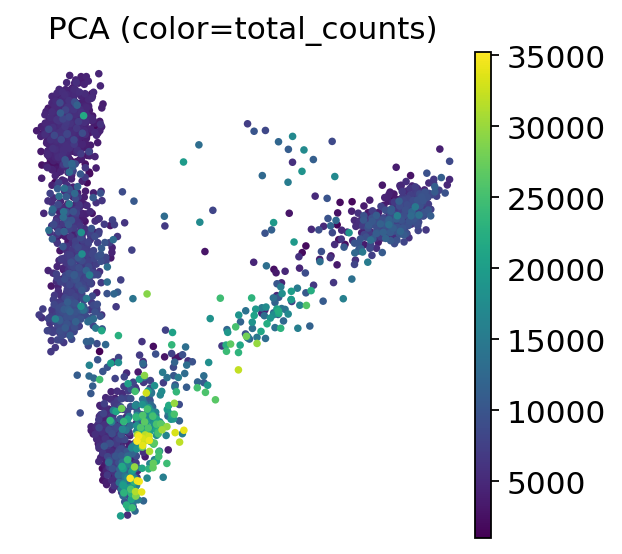

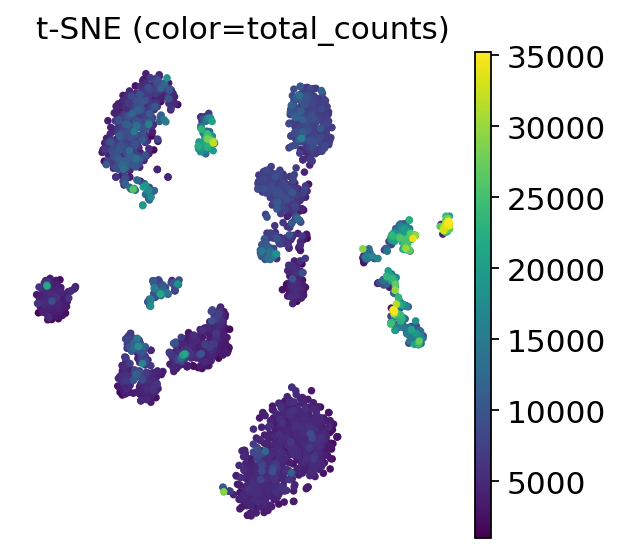

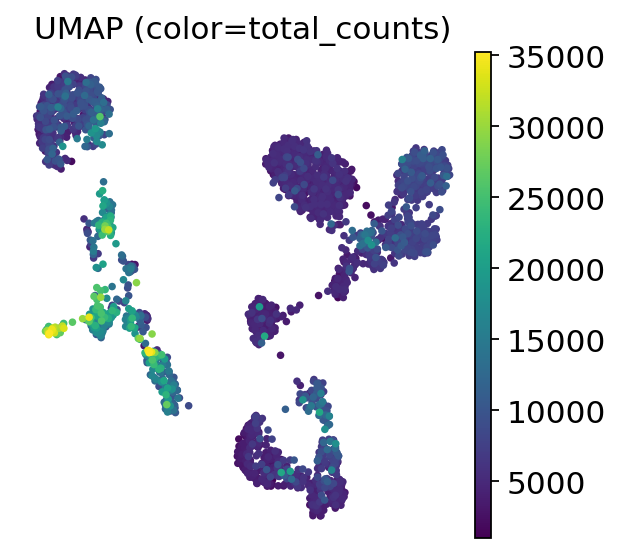

In [7]:
output = run_pipeline(adata,adata_raw,normalization_method='scran')

/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


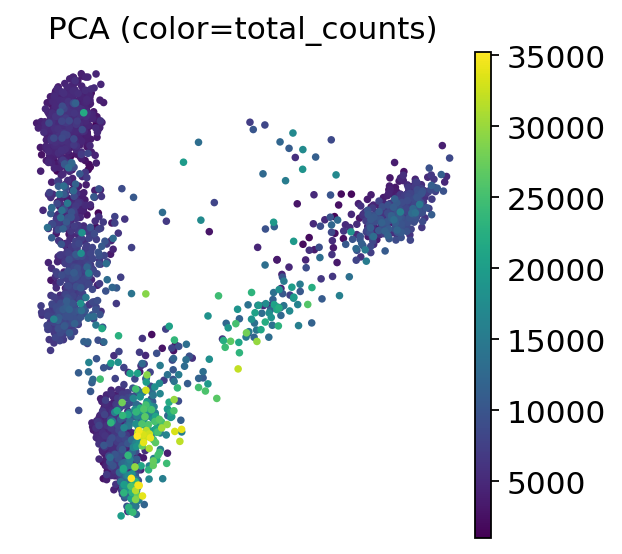

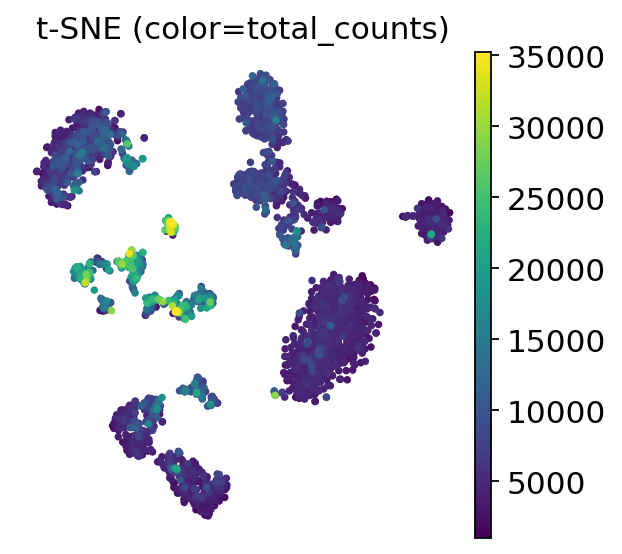

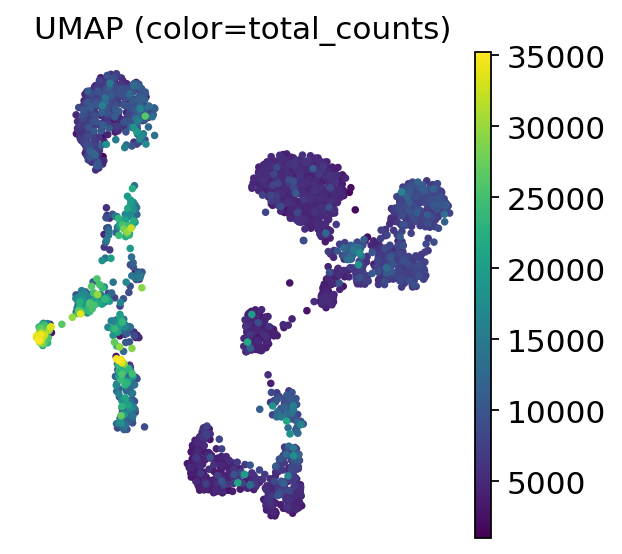

In [11]:
output = run_pipeline(adata,adata_raw,normalization_method='scran')